Pitch predictor project
===

By Sebastián Quirós Araya
---

Hello!

Developing this was the most fun I've had in quite a while when working with data. Regardless of where this ends, I'm grateful for the opportunity.

**Let's begin.**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
%precision %.3f

'%.3f'

## Data processing, selection and exploration

### Processing out empty data

We'll begin with a naïve inspection of the data provided.

In [67]:
metadata = pd.read_csv('pitch_by_pitch_metadata.csv',encoding='latin-1')
display(metadata)

,column_name,available_prior_to_pitch,description
0,uid,Yes,unique id
1,game_pk,Yes,unique game id
2,year,Yes,year
3,date,Yes,date
4,team_id_b,Yes,team_id for the batting team
5,team_id_p,Yes,team_id for the pitching team
6,inning,Yes,inning number
7,top,Yes,binary: is top half of inning
8,at_bat_num,Yes,incrementing at bat count for game
9,pcount_at_bat,Yes,pitches thrown in at bat


In [34]:
pitches=pd.read_csv('pitches',low_memory=False)

In [37]:
pitches.shape

(718961, 125)

In [45]:
pitches.head(2)

,uid,game_pk,year,date,team_id_b,team_id_p,inning,top,at_bat_num,pcount_at_bat,pcount_pitcher,balls,strikes,fouls,outs,is_final_pitch,final_balls,final_strikes,final_outs,start_tfs,start_tfs_zulu,batter_id,stand,b_height,pitcher_id,p_throws,at_bat_des,event,event2,event3,event4,away_team_runs,home_team_runs,score,pitch_des,pitch_id,type,pitch_tfs,pitch_tfs_zulu,x,y,sv_id,start_speed,end_speed,sz_top,sz_bot,pfx_x,pfx_z,px,pz,x0,z0,y0,vx0,vz0,vy0,ax,az,ay,break_length,break_y,break_angle,pitch_type,type_confidence,zone,nasty,spin_dir,spin_rate,cc,on_1b,on_2b,on_3b,runner1_id,runner1_start,runner1_end,runner1_event,runner1_score,runner1_rbi,runner1_earned,runner2_id,runner2_start,runner2_end,runner2_event,runner2_score,runner2_rbi,runner2_earned,runner3_id,runner3_start,runner3_end,runner3_event,runner3_score,runner3_rbi,runner3_earned,runner4_id,runner4_start,runner4_end,runner4_event,runner4_score,runner4_rbi,runner4_earned,runner5_id,runner5_start,runner5_end,runner5_event,runner5_score,runner5_rbi,runner5_earned,runner6_id,runner6_start,runner6_end,runner6_event,runner6_score,runner6_rbi,runner6_earned,runner7_id,runner7_start,runner7_end,runner7_event,runner7_score,runner7_rbi,runner7_earned,created_at,added_at,modified_at,modified_by
0,14143226,286874,2011,2011-03-31,108,118,1,1,1,1,1,0,0,0,0,0,2,1,1,201226,2011-03-31 20:12:26,430895,L,5-8,460024,R,"Maicer Izturis grounds out, second baseman Chris Getz to first baseman Kila Ka'aihue.",Groundout,NaN,NaN,NaN,0,0,NaN,Ball,3,B,201301.0,2011-03-31 20:13:01,105.58,180.46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-03-03 21:33:20,2016-03-03 21:33:20,2016-03-03 21:33:20,1
1,14143227,286874,2011,2011-03-31,108,118,1,1,1,2,2,1,0,0,0,0,2,1,1,201226,2011-03-31 20:12:26,430895,L,5-8,460024,R,"Maicer Izturis grounds out, second baseman Chris Getz to first baseman Kila Ka'aihue.",Groundout,NaN,NaN,NaN,0,0,NaN,Ball,4,B,201319.0,2011-03-31 20:13:19,99.57,170.96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-03-03 21:33:20,2016-03-03 21:33:20,2016-03-03 21:33:20,1


From the metadata and the ```head()```, it *seems* like there is quite a few rows that contain a lot of NaN. The data processing must begin with removing any columns that don't actually contain any data. We'll do a sweep of the columns and keep only those containing something.

In [39]:
data_cols = list()
for col in pitches.columns:
    if not pitches[col].isnull().all():
        data_cols.append(col)

In [40]:
pitches_data=pitches[data_cols]

### Filtering out variables unknown before the pitch

Now we think about the aim of the project: to predict the *next* pitch. This means, in a game situation, the only available information would be the one we have before the pitch is thrown. Therefore, all columns labeled "No" in metadata should not be taken into consideration, or else we risk creating a useless predictor which requires knowing the future!

Since we need a target to train the predictor on, we must also take into account the ```pitch_type``` column.

In [50]:
known_cols = list()

for i in range(len(metadata)):
    if metadata['column_name'][i] in data_cols and metadata['available_prior_to_pitch'][i] == 'Yes':
        known_cols.append(metadata['column_name'][i])

known_cols.append('pitch_type')

In [53]:
known_data = pitches_data[known_cols]

In [54]:
known_data.head()

,uid,game_pk,year,date,team_id_b,team_id_p,inning,top,at_bat_num,pcount_at_bat,pcount_pitcher,balls,strikes,fouls,outs,start_tfs,start_tfs_zulu,batter_id,stand,b_height,pitcher_id,p_throws,away_team_runs,home_team_runs,pitch_id,on_1b,on_2b,on_3b,pitch_type
0,14143226,286874,2011,2011-03-31,108,118,1,1,1,1,1,0,0,0,0,201226,2011-03-31 20:12:26,430895,L,5-8,460024,R,0,0,3,NaN,NaN,NaN,NaN
1,14143227,286874,2011,2011-03-31,108,118,1,1,1,2,2,1,0,0,0,201226,2011-03-31 20:12:26,430895,L,5-8,460024,R,0,0,4,NaN,NaN,NaN,NaN
2,14143228,286874,2011,2011-03-31,108,118,1,1,1,3,3,2,0,0,0,201226,2011-03-31 20:12:26,430895,L,5-8,460024,R,0,0,5,NaN,NaN,NaN,NaN
3,14143229,286874,2011,2011-03-31,108,118,1,1,1,4,4,2,1,0,0,201226,2011-03-31 20:12:26,430895,L,5-8,460024,R,0,0,6,NaN,NaN,NaN,NaN
4,14143230,286874,2011,2011-03-31,108,118,1,1,2,1,5,0,0,0,1,201354,2011-03-31 20:13:54,435062,R,5-10,460024,R,0,0,10,NaN,NaN,NaN,NaN


What we have now is a dataset containing only the things known before the pitch and a target. Some entries are NaN, so we leave only those where we have the information about what pitch it was.

In [49]:
float(pitches['pitch_type'].isnull().sum()/len(pitches.pitch_type)*100) 
# about 0.3% of the dataset has no pitch type info. we can discard this subset without worries.

0.32

In [60]:
final = known_data[pitches['pitch_type'].notnull()]
final.to_csv('cut_data.csv') # saved for later, RAM ain't cheap these days...

(716681, 29)

In [3]:
data = pd.read_csv('cut_data.csv', usecols=range(1,30))

In [68]:
data.columns

Index(['uid', 'game_pk', 'year', 'date', 'team_id_b', 'team_id_p', 'inning',
       'top', 'at_bat_num', 'pcount_at_bat', 'pcount_pitcher', 'balls',
       'strikes', 'fouls', 'outs', 'start_tfs', 'start_tfs_zulu', 'batter_id',
       'stand', 'b_height', 'p_throws', 'away_team_runs', 'home_team_runs',
       'pitch_id', 'on_1b', 'on_2b', 'on_3b', 'pitch_type'],
      dtype='object')

### Pitch type frequency

In [5]:
freq = data['pitch_type'].value_counts(normalize=True)
freq

pitch_type
FF    0.332841
SL    0.153145
SI    0.122425
FT    0.113099
CH    0.101358
CU    0.078667
FC    0.058188
FS    0.014655
KC    0.011846
KN    0.006209
IN    0.005662
PO    0.000780
FO    0.000459
FA    0.000285
EP    0.000187
SC    0.000167
UN    0.000024
AB    0.000003
Name: proportion, dtype: float64

In [6]:
np.sum(freq[9:])

0.014

It seems there are some pitch types that don't appear very frequently. While 4-seam fastballs make up almost a third of the sample, pitches like an eephus, a knuckleball, forkballs, and odd events like pitch-outs or automatic balls make up a very small proportion (about 1,4% in total).

Guessing an eephus, a knuckleball, etc... should not be a feature of our predictor. We should therefore remove those pitches from our dataset.

In [12]:
for i in freq[9:].index:
    data = data.drop(data[data['pitch_type']==i].index)

### A possibility: training an individual predictor for each pitcher?

In [13]:
len(data['pitcher_id'].unique())

662

In [30]:
pitchers = data['pitcher_id'].unique()

lengths = [len(data[data['pitcher_id']==i]) for i in pitchers]

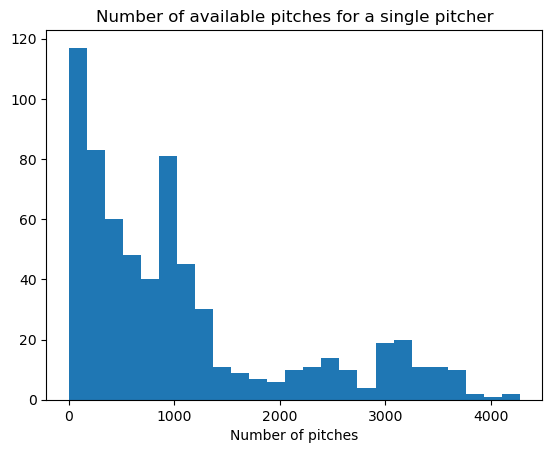

In [52]:
plt.hist(lengths,bins=25);
plt.xlabel('Number of pitches');
plt.title('Number of available pitches for a single pitcher');

Many pitchers have thousands of pitches but the vast majority are under a thousand. Thus, we'll use the entire dataset, while acknowledging that this can smooth out the nuances that make different pitchers different from each other.

We'll also drop the `pitcher_id` column.

In [54]:
data = data.drop(columns='pitcher_id')

### Score and count data

A pitcher will pitch differently in a tied game than in a blowout. He will also pitch very differently for a 1-2 and a 3-0 count. We need to find a way to summarize the information available into score and count data.

For the score, we'll create a new variable called `score_diff` which represents the pitching team's current advantage or disadvantage. This requires analyzing whether the pitching team is the away or home team and whether it's the top or bottom of the inning (both available in the data already).

For the count data, we can't assign a single difference value to the count (as we do for the score), given the huge difference between 0-1 and 1-2 for example. In both cases a pitcher has one more strike than balls, but the approach will change drastically.
Since we have a limited number of possible counts: 0-0,1-0,2-0,etc..., we simply assign a numeric value to each of these. (This is not the most elegant solution...)

Brief notes:
- The quantity `2*data['top']-1` evaluates to 1 for the top of the inning (i.e. the home team is pitching), and to -1 for the bottom of the inning. Thus, for a pitcher on the home team, the `score_diff` is `home - away`, and for an away pitcher it's `away - home`.
- Once we have calculate `score_diff`, we get rid of `top` and the individual team scores. The data can be skewed one way or another depending on the bottom/top of the inning for the 9th inning or later. We choose to ignore that and drop `inning`.
- We can get a clean mapping from balls and strikes to a unique count identifier with the formula
$$\mathrm{count} = 3\times \mathrm{balls} + \mathrm{strikes}$$

In [88]:
data.columns

Index(['uid', 'game_pk', 'year', 'date', 'team_id_b', 'team_id_p', 'inning',
       'at_bat_num', 'pcount_at_bat', 'pcount_pitcher', 'balls', 'strikes',
       'fouls', 'outs', 'start_tfs', 'start_tfs_zulu', 'batter_id', 'stand',
       'b_height', 'p_throws', 'pitch_id', 'on_1b', 'on_2b', 'on_3b',
       'pitch_type', 'score_diff'],
      dtype='object')

In [87]:
data['score_diff'] = (2*data['top']-1)*(data['home_team_runs']-data['away_team_runs'])
data = data.drop(columns=['top','home_team_runs','away_team_runs','inning'])

In [92]:
data['count'] = 3 * data['balls'] + data['strikes']
data = data.drop(columns=['balls','strikes'])

### Other "numerizations"

Similarly, we assign a single value to each different pitch type. We assign a LHB/LHP a 0 and a RHB/RHP a 1. We also use [an online height table](https://www.uhsussex.nhs.uk/wp-content/uploads/2023/03/Height-Conversion-Chart.pdf) to get the height in cm.

In [104]:
data = data.replace(freq[0:9].index, range(9))

In [103]:
data = data.replace(['L', 'R'], [0, 1])

In [114]:
heights = data.b_height.unique()
heights_cm = [178,185,193,183,173,188,191,180,196,198,175,200,208,203,206,168,165,170]

data = data.replace(heights, heights_cm)

/tmp/ipykernel_25248/78217306.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace(heights, heights_cm)


### Final variable assessment

Finally, we look at different columns we could drop. Since this code will run locally, we're more aggressive in dropping some variables. With more time, ideally there would be a trial-and-error period in which to see which are good options to keep.

- **Redundant variables:**
    - `start_tfs(_zulu)` (tiredness already taken into account with the pitch count)
    - `pitch_id`
    - `at_bat_num` (same as `start_tfs`)
- **Not much baseball info:**
    - `uid` 
    - `game_pk`
    - `year`
    - `date`
(the last two could reasonably give some information but for now we ignore them)

In [107]:
data = data.drop(columns=['uid', 'game_pk', 'year', 'date', 'at_bat_num', 'start_tfs', 'start_tfs_zulu'])

In [118]:
data.to_csv('train_data.csv', index=False)

## Training a classifier!

Before actually training the classifier, it would be necessary to spend some time visualizing data and using some metrics of correlation (such as the Kolmogorov-Smirnov test). However, since I have already used some baseball intuition and the problem setup to cut many variables, we leave the ones in this set, potentially increasing the error but saving time.

In [3]:
train_data = pd.read_csv('train_data.csv')
train_data.head()

,team_id_b,team_id_p,pcount_at_bat,pcount_pitcher,fouls,outs,batter_id,stand,b_height,p_throws,pitch_id,on_1b,on_2b,on_3b,pitch_type,score_diff,count
0,118,108,1,1,0,0,449107,1,178,1,51,NaN,NaN,NaN,0,0,0
1,118,108,2,2,0,0,449107,1,178,1,52,NaN,NaN,NaN,0,0,1
2,118,108,3,3,0,0,449107,1,178,1,53,NaN,NaN,NaN,0,0,4
3,118,108,4,4,0,0,449107,1,178,1,54,NaN,NaN,NaN,0,0,7
4,118,108,5,5,1,0,449107,1,178,1,55,NaN,NaN,NaN,0,0,8


In [4]:
data = train_data.drop(columns='pitch_type').values
labels = train_data['pitch_type'].values

In [21]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.utils import compute_sample_weight
from xgboost import XGBClassifier

X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=.2, stratify=labels)

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

bdt_weighted = XGBClassifier()
bdt_weighted.fit(X_train, y_train, sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [23]:
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

preds_proba = bdt_weighted.predict_proba(X_test)
preds = bdt_weighted.predict(X_test)

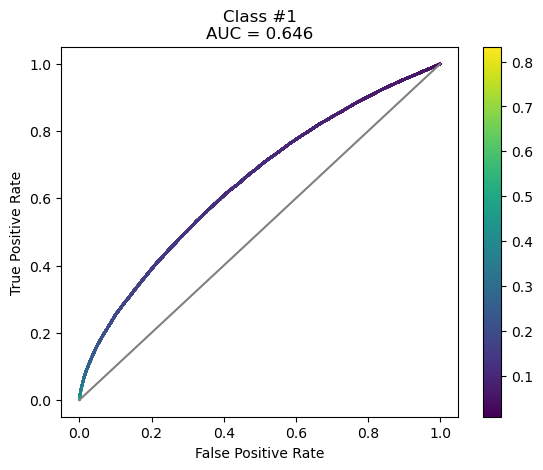

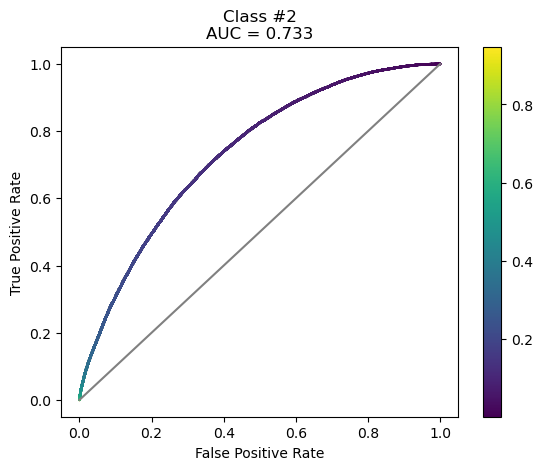

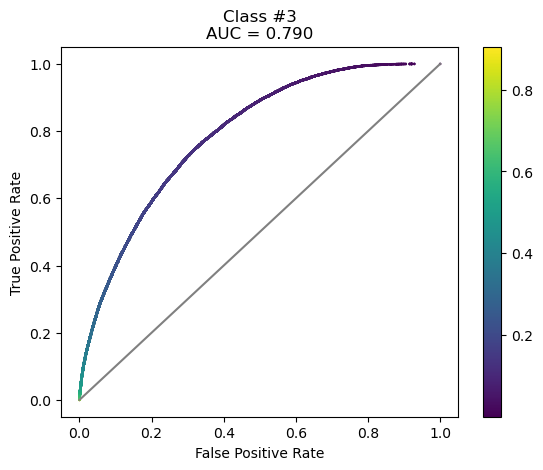

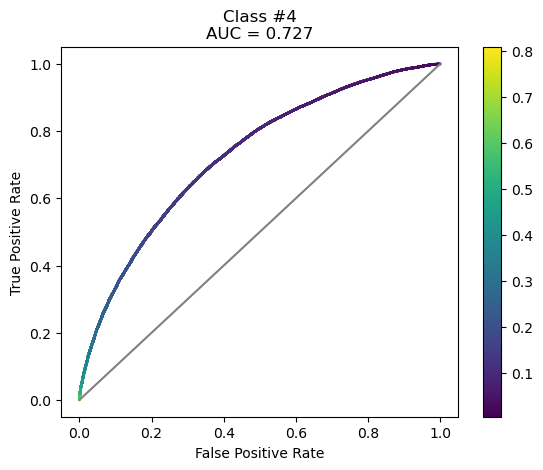

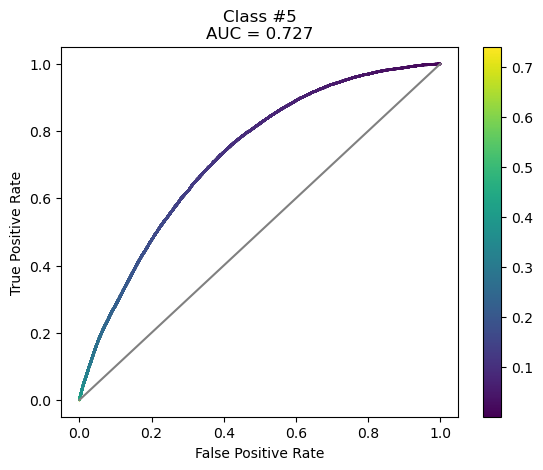

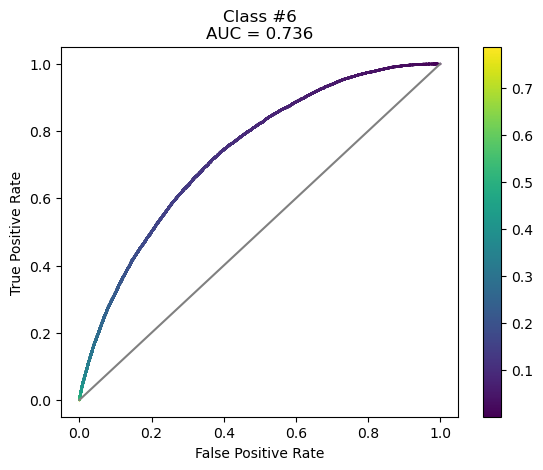

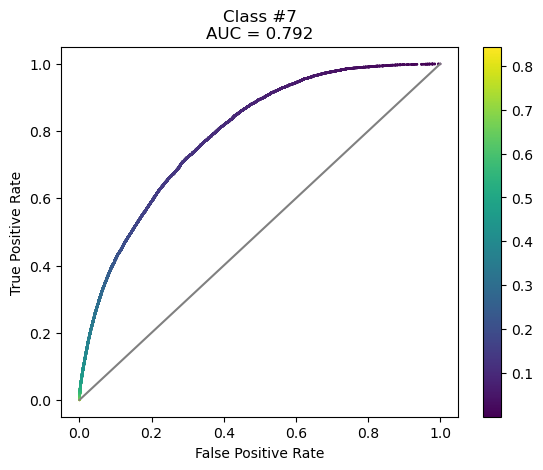

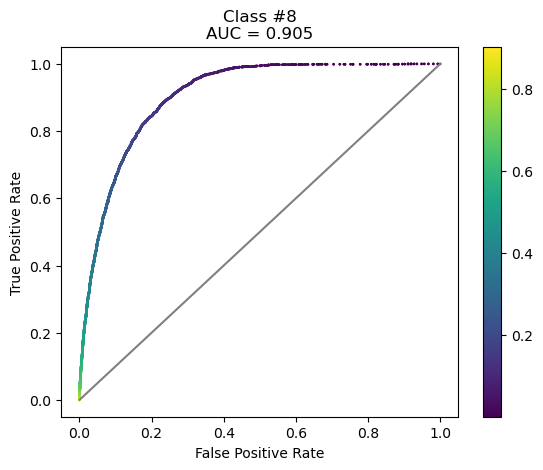

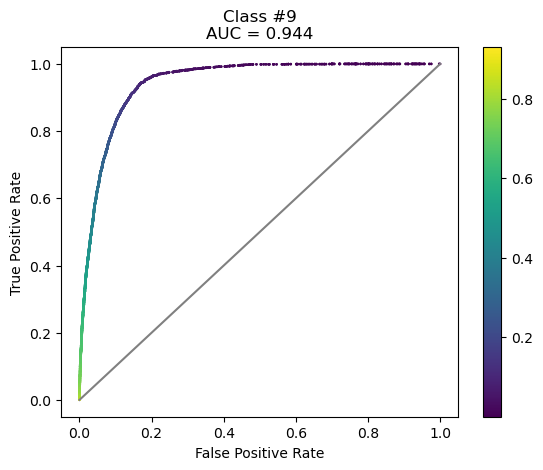

In [24]:
for i in range(9):
    y_binary = (y_test == i).astype(int)
    preds_proba_i = preds_proba[:, i]

    fpr, tpr, t = roc_curve(y_binary, preds_proba_i)
    auc = roc_auc_score(y_binary, preds_proba_i)

    plt.scatter(fpr, tpr, s=0.75, c=t)
    plt.plot(fpr, fpr, color='gray')
    plt.title(f'Class #{i+1}\nAUC = {auc:.3f}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.colorbar()
    plt.savefig(f'ROC_curve_{i}.pdf')
    plt.show()

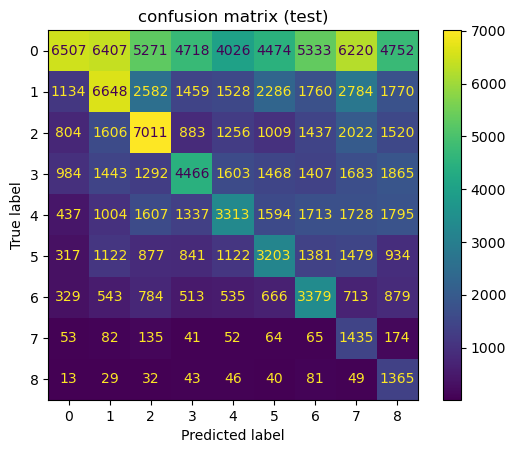

In [33]:
cm = confusion_matrix(y_test, preds, labels=range(9))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(9))
disp.plot()
_ = disp.ax_.set_title("confusion matrix (test)")

## A (non-exhaustive) list of possible improvements

There is obviously quite a lot to be done to improve this model. 

### Available data to be integrated
If this were a project to be developed fully, it would be possible to add already available data into the dataset.
- **Advanced metrics such as [Leverage Index](https://tht.fangraphs.com/crucial-situations/):** A pitcher might lean on one of their pitches for high-pressure situations.
- **[Known pitch mix vs. LHB/RHB](https://baseballsavant.mlb.com/savant-player/cam-schlittler-693645?stats=statcast-r-pitching-mlb#pitch_tracking)**
- **Individual pitcher modelling**: Adding enough data to train a predictor for each individual opposing pitcher could make for a more accurate model.

### Potential sources of error and improvements
However, most of the error comes from an imperfect modelling and training.
- **No data visualization and optimal feature selection:** Before training the classifier, it would be ideal to use something like a `pairplot()` to see which variables are most correlated with pitch type.
- **Normalization**: Variables could be normalized between 0 and 1 to get more numerically stable calculations.
- **Data visualization and clarity:** It'd be better to plot using the names of the pitches in the titles and axes.

## Conclusion

We have trained an XGB Classifier that takes in data known before the pitch and outputs the likeliest upcoming pitch type. The model shows serious flaws in prediction. For example, it is almost equally likely to predict a fastball, slider or sinker when the pitch is a fastball. This model would need some serious tuning.

### Future work
Possible future work to improve this model includes the following steps.

- **Weights:** The weights added could be better. When there were no weights, the model tended to predict mostly fastballs as they dominate the dataset. However, when I added weights it went in the opposite direction and now hesitates to predict a fastball is coming. A nice middle could probably be found.
- **Stratified k-folding:** We could use stratified k-folding in order to take full advantage of the dataset. In truth, I tried this approach but I had only done it for a 2-class `XGBClassifier()` and it was taking too long to adapt to multiclass. It would likely not take too much time but it's one area where I could have done this better.
- **Pitch type grouping:** This is probably the most useful one. To a batter, it's more important to know something like fastball vs. off-speed vs. breaking ball, since they will most likely be aware of the pitcher's repertoire. That is, a classifier that tells them "off-speed" when they know the pitcher throws a splitter, is more useful than one which zeroes in on the exact type of off-speed pitch but can make more mistakes. I think if I were to continue this work, this is where I would spend more time.